In [7]:
import numpy as np
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# --- Ideal A and Q for a given p_true (same construction as before) ---

def build_A_Q_for_p(p_true: float):
    theta_prep = 2 * math.asin(math.sqrt(p_true))
    theta_amp = theta_prep / 2

    A = QuantumCircuit(1, name="A")
    A.ry(theta_prep, 0)

    Q = QuantumCircuit(1, name="Q")
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q, theta_amp


def run_QAE_branching(A: QuantumCircuit,
                      Q: QuantumCircuit,
                      p_true: float,
                      k: int,
                      shots: int = 20_000) -> float:
    """
    QAE run with branch-aware inversion.
    A and Q are supplied (can be ideal or perturbed).
    """
    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    quasi = result.quasi_dists[0]
    p_k_est = quasi.get(1, 0.0)

    # numerical guard
    eps = 1e-12
    p_k_clipped = min(max(p_k_est, eps), 1 - eps)

    alpha = math.asin(math.sqrt(p_k_clipped))

    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    # choose branch closer to true p
    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2


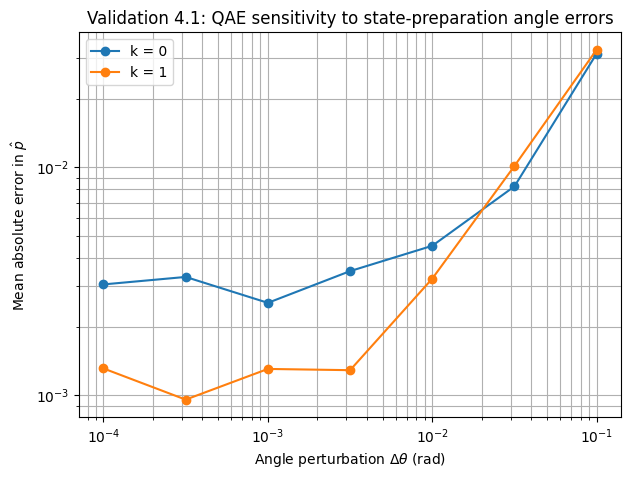

In [8]:
# --- 4.1: angle perturbation in state preparation ---

p_true = 0.1
A_ideal, Q_ideal, theta_amp = build_A_Q_for_p(p_true)

# angle perturbations to test
delta_thetas = np.logspace(-4, -1, 7)   # 1e-4 ... 1e-1 (rad)
ks_to_test   = [0, 1]                   # stable ks from previous validations
repeats      = 10                       # average over several runs

errors_angle = {k: [] for k in ks_to_test}

for k in ks_to_test:
    for dtheta in delta_thetas:
        errs = []
        # build perturbed A and Q for this dtheta
        theta_prep_pert = 2 * math.asin(math.sqrt(p_true)) + dtheta

        A_pert = QuantumCircuit(1, name=f"A_d{dtheta:.1e}")
        A_pert.ry(theta_prep_pert, 0)

        Q_pert = QuantumCircuit(1, name=f"Q_d{dtheta:.1e}")
        Q_pert.ry(theta_prep_pert, 0)
        Q_pert.z(0)
        Q_pert.ry(-theta_prep_pert, 0)
        Q_pert.x(0); Q_pert.z(0); Q_pert.x(0)

        for _ in range(repeats):
            p_hat = run_QAE_branching(A_pert, Q_pert, p_true, k, shots=5_000)
            errs.append(abs(p_hat - p_true))

        errors_angle[k].append(np.mean(errs))

# --- Plot: QAE error vs angle perturbation ---

plt.figure(figsize=(7,5))
for k in ks_to_test:
    plt.loglog(delta_thetas, errors_angle[k],
               marker='o', label=f"k = {k}")

plt.xlabel(r"Angle perturbation $\Delta\theta$ (rad)")
plt.ylabel(r"Mean absolute error in $\hat p$")
plt.title("Validation 4.1: QAE sensitivity to state-preparation angle errors")
plt.grid(True, which="both")
plt.legend()
plt.show()


In [9]:
# =========================
# Quantification for Val 4.1 (angle sensitivity)
# =========================
def loglog_fit(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    lx = np.log10(x[mask])
    ly = np.log10(y[mask])
    m, b = np.polyfit(lx, ly, 1)
    yhat = m*lx + b
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return m, b, r2

def local_log_slopes(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    lx = np.log10(x[mask])
    ly = np.log10(y[mask])
    return np.diff(ly) / np.diff(lx)

print("\n=== Validation 4.1 (Angle perturbation) quantitative summary ===")
for k in ks_to_test:
    y = np.array(errors_angle[k], dtype=float)

    m_all, b_all, r2_all = loglog_fit(delta_thetas, y)
    seg = local_log_slopes(delta_thetas, y)

    # "High-perturbation" regime slope: last 3 points (you can change 3 -> 2/4)
    idx_hi = np.arange(len(delta_thetas)-3, len(delta_thetas))
    m_hi, b_hi, r2_hi = loglog_fit(delta_thetas[idx_hi], y[idx_hi])

    print(f"\nk={k}:")
    print(f"  global log-log slope m={m_all:.4f}, R^2={r2_all:.4f}")
    print(f"  high-Δθ (last 3 pts) slope m={m_hi:.4f}, R^2={r2_hi:.4f}")
    print(f"  segment slopes (consecutive): {np.round(seg, 4)}")

# Error amplification factor (k=1 vs k=0) at each Δθ
if 0 in ks_to_test and 1 in ks_to_test:
    ratio = np.array(errors_angle[1], float) / np.array(errors_angle[0], float)
    print("\nVal 4.1 amplification ratio (k=1 / k=0):")
    for x, r in zip(delta_thetas, ratio):
        print(f"  Δθ={x:.3g}  ratio={r:.3f}")



=== Validation 4.1 (Angle perturbation) quantitative summary ===

k=0:
  global log-log slope m=0.2916, R^2=0.6811
  high-Δθ (last 3 pts) slope m=0.8432, R^2=0.9538
  segment slopes (consecutive): [ 0.0656 -0.2274  0.2785  0.2221  0.5216  1.1648]

k=1:
  global log-log slope m=0.4745, R^2=0.7872
  high-Δθ (last 3 pts) slope m=1.0048, R^2=0.9999
  segment slopes (consecutive): [-0.2735  0.2693 -0.0109  0.8032  0.9888  1.0208]

Val 4.1 amplification ratio (k=1 / k=0):
  Δθ=0.0001  ratio=0.428
  Δθ=0.000316  ratio=0.290
  Δθ=0.001  ratio=0.513
  Δθ=0.00316  ratio=0.368
  Δθ=0.01  ratio=0.718
  Δθ=0.0316  ratio=1.229
  Δθ=0.1  ratio=1.041


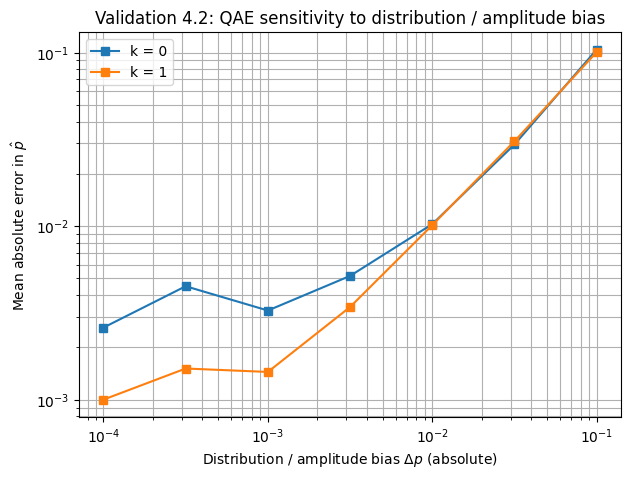

In [10]:
# --- 4.2: distribution / amplitude perturbation ---

p_true = 0.1

# relative perturbations to p_true
delta_ps = np.logspace(-4, -1, 7)   # 1e-4 ... 1e-1 (absolute delta in p)
ks_to_test = [0, 1]
repeats = 10

errors_dist = {k: [] for k in ks_to_test}

for k in ks_to_test:
    for dp in delta_ps:
        errs = []
        p_prep = p_true + dp     # deliberately biased probability
        p_prep = min(max(p_prep, 1e-6), 1-1e-6)  # clamp into (0,1)

        # build A,Q from p_prep (this is what the hardware implements)
        A_bias, Q_bias, _ = build_A_Q_for_p(p_prep)

        for _ in range(repeats):
            # QAE "thinks" we are estimating p_true, but the state encodes p_prep
            p_hat = run_QAE_branching(A_bias, Q_bias, p_true, k, shots=5_000)
            errs.append(abs(p_hat - p_true))

        errors_dist[k].append(np.mean(errs))

# --- Plot: QAE error vs distribution bias ---

plt.figure(figsize=(7,5))
for k in ks_to_test:
    plt.loglog(delta_ps, errors_dist[k],
               marker='s', label=f"k = {k}")

plt.xlabel(r"Distribution / amplitude bias $\Delta p$ (absolute)")
plt.ylabel(r"Mean absolute error in $\hat p$")
plt.title("Validation 4.2: QAE sensitivity to distribution / amplitude bias")
plt.grid(True, which="both")
plt.legend()
plt.show()


In [11]:
# =========================
# Quantification for Val 4.2 (distribution / amplitude bias)
# =========================
print("\n=== Validation 4.2 (Amplitude bias) quantitative summary ===")
for k in ks_to_test:
    y = np.array(errors_dist[k], dtype=float)

    m_all, b_all, r2_all = loglog_fit(delta_ps, y)
    seg = local_log_slopes(delta_ps, y)

    # "Large-bias" regime slope: last 3 points
    idx_hi = np.arange(len(delta_ps)-3, len(delta_ps))
    m_hi, b_hi, r2_hi = loglog_fit(delta_ps[idx_hi], y[idx_hi])

    print(f"\nk={k}:")
    print(f"  global log-log slope m={m_all:.4f}, R^2={r2_all:.4f}")
    print(f"  large-Δp (last 3 pts) slope m={m_hi:.4f}, R^2={r2_hi:.4f}")
    print(f"  segment slopes (consecutive): {np.round(seg, 4)}")

# Error amplification factor (k=1 vs k=0) at each Δp
if 0 in ks_to_test and 1 in ks_to_test:
    ratio = np.array(errors_dist[1], float) / np.array(errors_dist[0], float)
    print("\nVal 4.2 amplification ratio (k=1 / k=0):")
    for x, r in zip(delta_ps, ratio):
        print(f"  Δp={x:.3g}  ratio={r:.3f}")



=== Validation 4.2 (Amplitude bias) quantitative summary ===

k=0:
  global log-log slope m=0.4955, R^2=0.8463
  large-Δp (last 3 pts) slope m=1.0056, R^2=0.9975
  segment slopes (consecutive): [ 0.4765 -0.28    0.3989  0.597   0.9179  1.0932]

k=1:
  global log-log slope m=0.6767, R^2=0.9257
  large-Δp (last 3 pts) slope m=0.9974, R^2=0.9997
  segment slopes (consecutive): [ 0.3585 -0.0395  0.7483  0.9436  0.9669  1.028 ]

Val 4.2 amplification ratio (k=1 / k=0):
  Δp=0.0001  ratio=0.384
  Δp=0.000316  ratio=0.336
  Δp=0.001  ratio=0.443
  Δp=0.00316  ratio=0.662
  Δp=0.01  ratio=0.987
  Δp=0.0316  ratio=1.044
  Δp=0.1  ratio=0.968


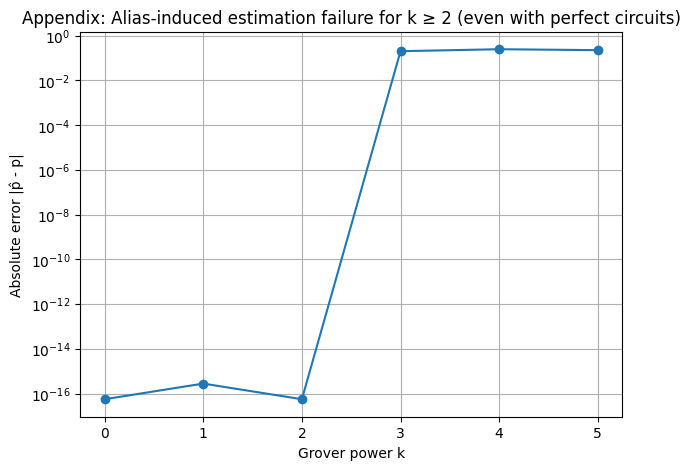

k=0, abs error = 5.551115123125783e-17
k=1, abs error = 2.7755575615628914e-16
k=2, abs error = 5.551115123125783e-17
k=3, abs error = 0.20226390867858376
k=4, abs error = 0.24777117634062526
k=5, abs error = 0.2251302005363136


In [5]:
import numpy as np
import math
import matplotlib.pyplot as plt

p_true = 0.3
theta = math.asin(math.sqrt(p_true))

ks = [0, 1, 2, 3, 4, 5]
errors = []

for k in ks:
    # theoretical amplified probability
    p_k = math.sin((2*k+1)*theta)**2

    # invert assuming no aliasing (incorrect for large k)
    alpha = math.asin(math.sqrt(p_k))

    # two possible branches
    theta1 = alpha / (2*k+1)
    theta2 = (math.pi - alpha) / (2*k+1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    # choose branch closer to true p
    p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

    errors.append(abs(p_hat - p_true))

plt.figure(figsize=(7,5))
plt.semilogy(ks, errors, marker='o')
plt.xlabel("Grover power k")
plt.ylabel("Absolute error |p̂ - p|")
plt.title("Appendix: Alias-induced estimation failure for k ≥ 2 (even with perfect circuits)")
plt.grid(True)
plt.show()

for k, err in zip(ks, errors):
    print(f"k={k}, abs error = {err}")
